<a href="https://colab.research.google.com/github/melaniee-sudo/machine-learning-udg-tareas/blob/main/p8_knn_para_regresion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
#KNN se utiliza para predecir un valor numerico continuo
#en lugar de una clase (como en la p7).
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.neighbors import KNeighborsRegressor

#cargar los datos
diabetes = load_diabetes()

#primera columna y primeras 100 instancias
X = diabetes.data[:100, 0].reshape(-1, 1)
y = diabetes.target[:100]

#valores solicitados
valores_k = [1, 5, 15]
distancias = ["euclidean", "manhattan"]


#generar una linea con posibles valores de entrada
X_linea = np.linspace(
    X.min(),
    X.max(),
    500
).reshape(-1, 1)


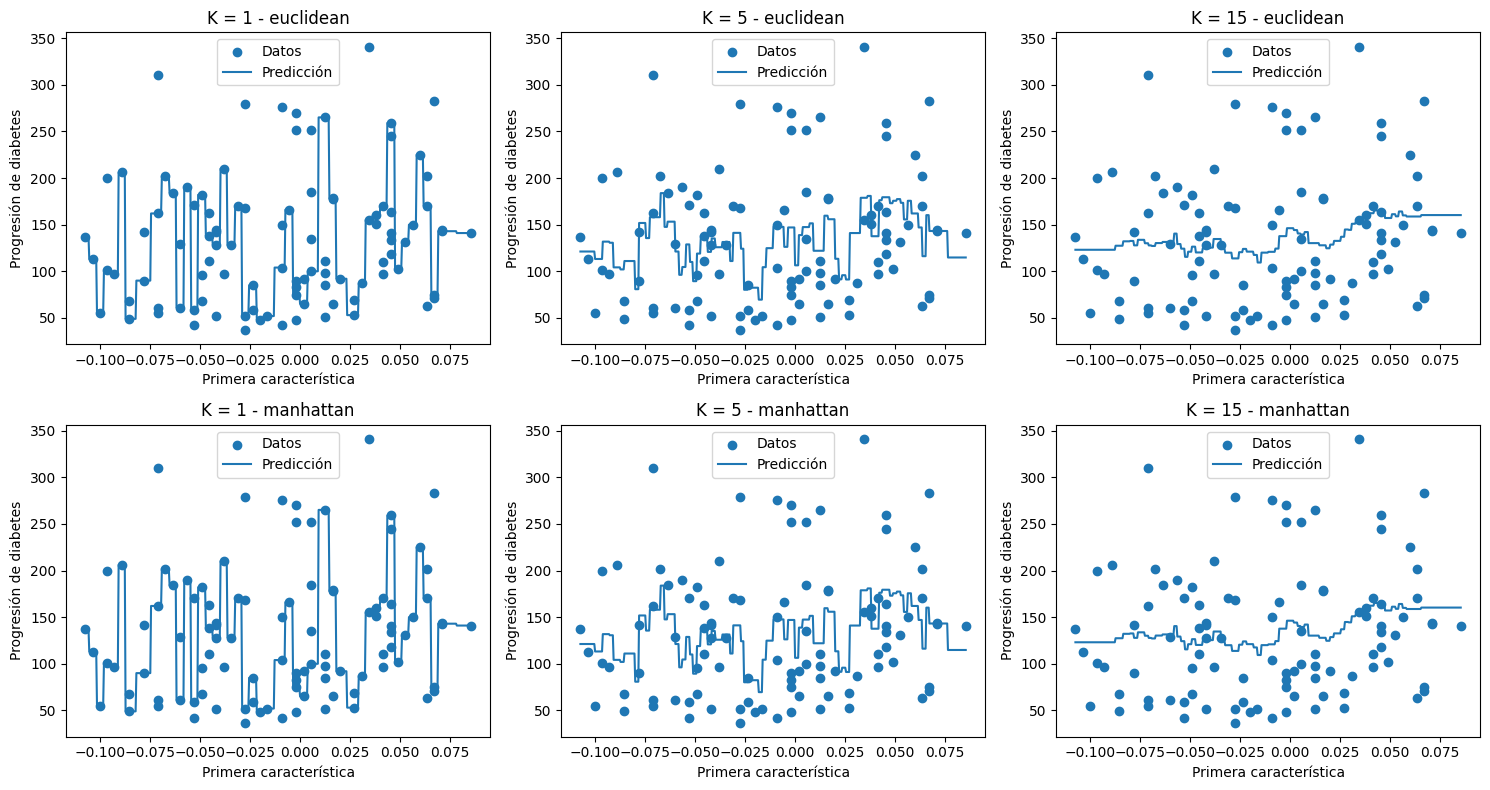

In [3]:
#Crear una figura con 6 graficas
plt.figure(figsize=(15, 8))

posicion = 1


for distancia in distancias:

    for k in valores_k:

        #crear modelo
        knn = KNeighborsRegressor(
            n_neighbors=k,
            metric=distancia
        )

        #entrenar
        knn.fit(X, y)

        #predecir para cada punto de la linea
        y_pred = knn.predict(X_linea)


        #grafica
        plt.subplot(2, 3, posicion)

        plt.scatter(
            X,
            y,
            label="Datos"
        )

        plt.plot(
            X_linea,
            y_pred,
            label="Predicción"
        )

        plt.xlabel("Primera caracteristica")
        plt.ylabel("Progresión de diabetes")

        plt.title(
            f"K = {k} - {distancia}"
        )

        plt.legend()

        posicion += 1


plt.tight_layout()
plt.show()